## By: **Dominikus Krisna Herlambang | ©2024**

In [ ]:
!pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 52.5 MB/s eta 0:00:00


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 48.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px

In [ ]:
df = xr.open_dataset('/erie_lld.grd')
df

<xarray.Dataset> Size: 69MB
Dimensions:  (x: 7201, y: 2401)
Coordinates:
  * x        (x) float64 58kB -84.0 -84.0 -84.0 -84.0 ... -78.0 -78.0 -78.0
  * y        (y) float64 19kB 41.0 41.0 41.0 41.0 41.0 ... 43.0 43.0 43.0 43.0
Data variables:
    z        (y, x) float32 69MB ...
Attributes:
    Conventions:  COARDS/CF-1.0
    title:        erie.grd
    history:      grdmath erie_igld.grd 173.5 SUB = erie_lld.grd
    GMT_version:  4.5.7 [64-bit]

/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


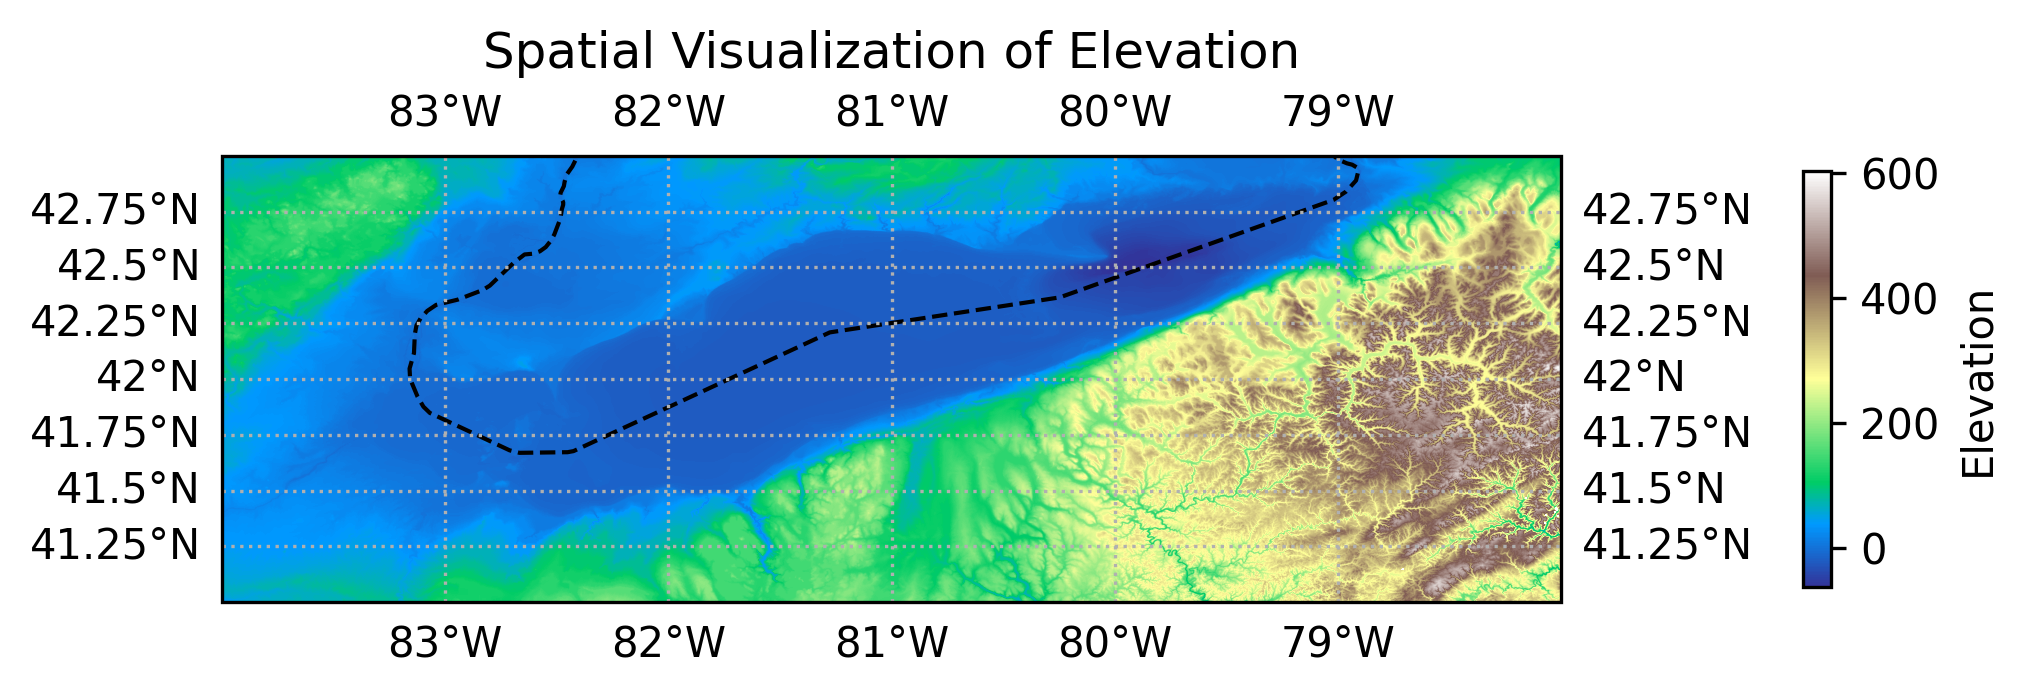

In [ ]:
# Create a figure and axes with a cartopy projection
fig, ax = plt.subplots(figsize=(8, 6), dpi=300,
                       subplot_kw={'projection': ccrs.PlateCarree()})

elevation = df['z'].values
x = df['x'].values
y = df['y'].values

# Plot the data as an image using imshow
im = ax.imshow(elevation, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', cmap='terrain', transform=ccrs.PlateCarree())

# Add gridlines
gl = ax.gridlines(draw_labels=True, linestyle=':')
gl.xlabels_top = False
gl.ylabels_right = False
# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle='--')

# Add a colorbar
cbar = fig.colorbar(im, ax=ax,shrink=0.3, aspect=15, orientation='vertical',
                    pad=0.13, label='Elevation')

# Add labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Visualization of Elevation')

# Show the plot
plt.show()

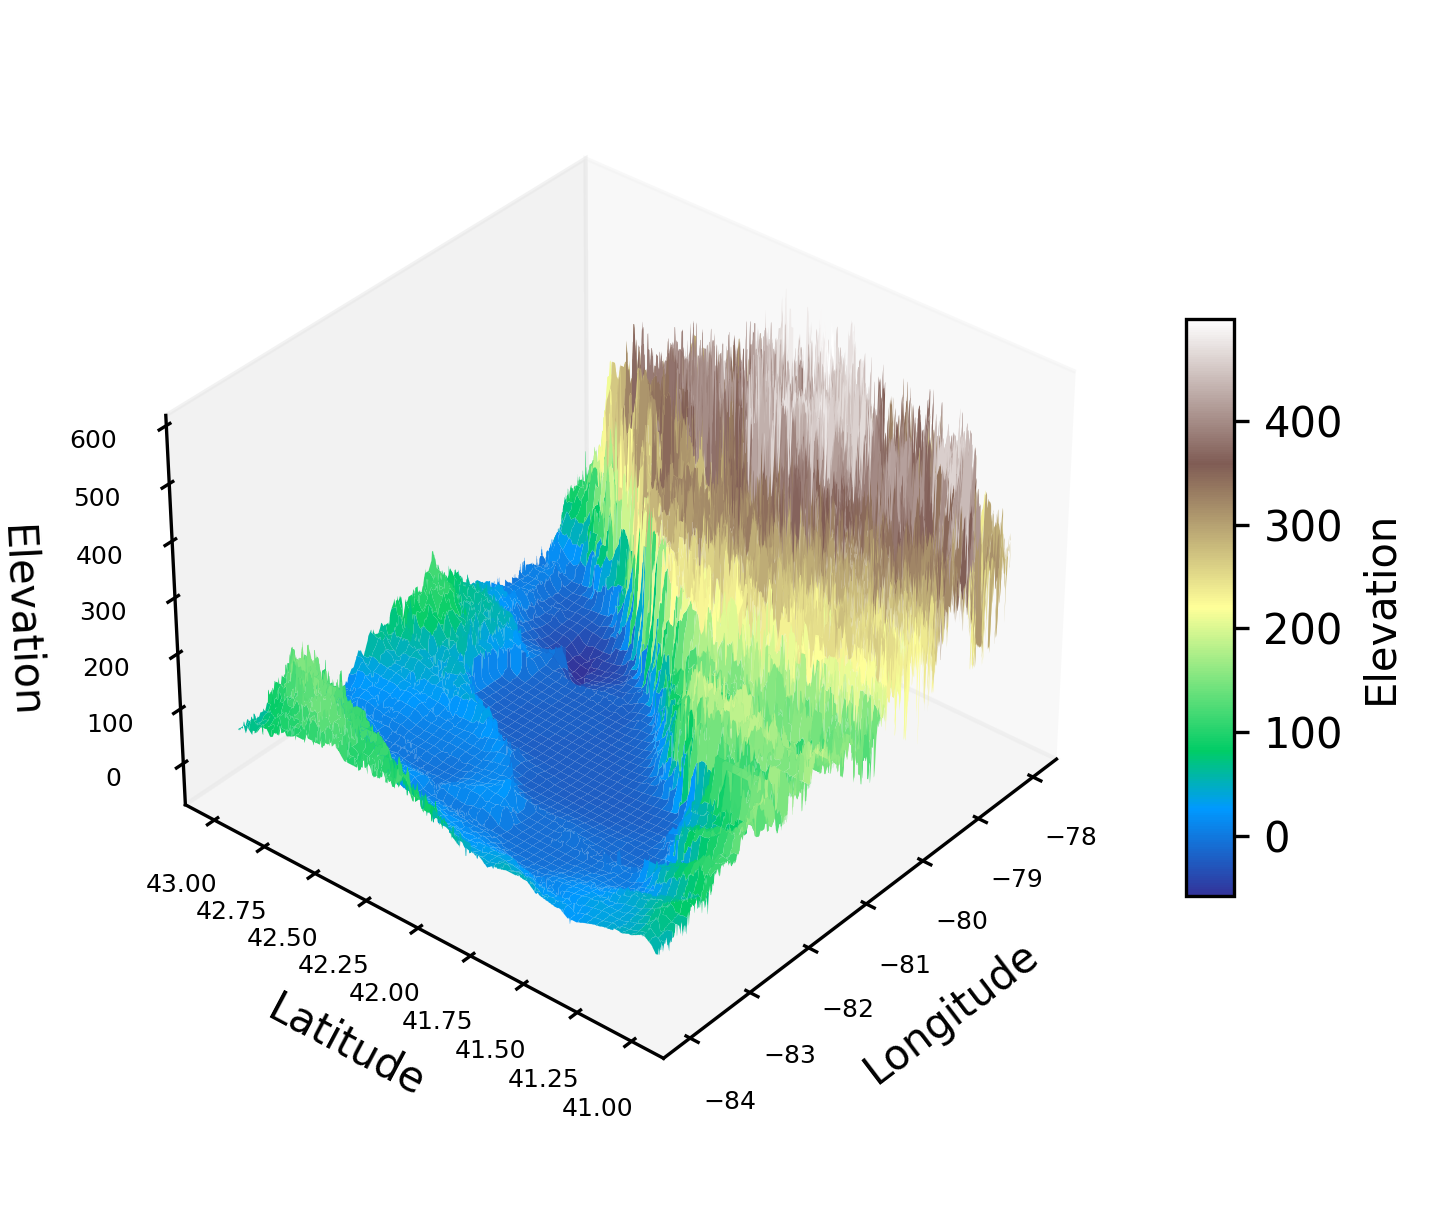

In [ ]:
fig = plt.figure(figsize=(10, 5),dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for plotting the surface
X, Y = np.meshgrid(x, y)

# Plot the surface using plot_surface
surf = ax.plot_surface(X, Y, elevation, cmap='terrain',linewidth=0, antialiased=True)

# Add a colorbar
fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.0005, label='Elevation')

# Add gridlines
ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=6)

# Add labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Elevation')

# Rotate the view
ax.view_init(elev=35, azim=220)  # Adjust elevation and azimuth as needed
ax.set_box_aspect(None, zoom=0.85)

# Show the plot
plt.show()

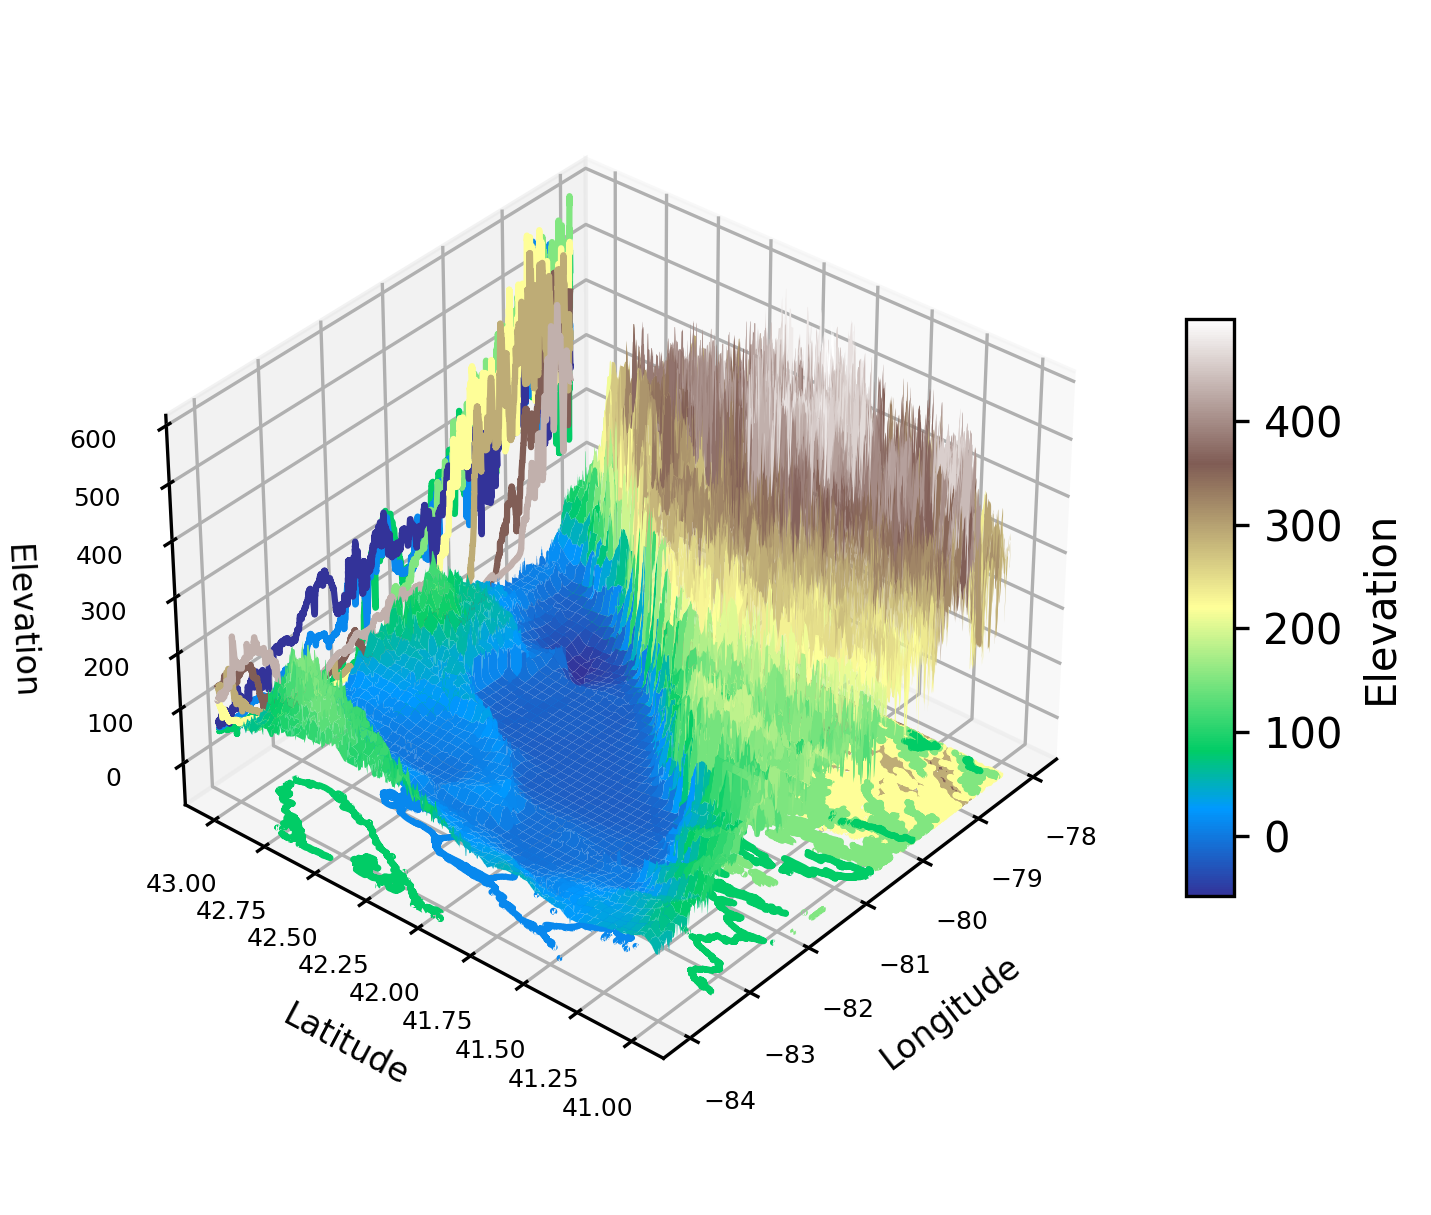

In [ ]:
fig = plt.figure(figsize=(10, 5),dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for plotting the surface
X, Y = np.meshgrid(x, y)

# Plot the surface using plot_surface
surf = ax.plot_surface(X, Y, elevation, cmap='terrain',linewidth=0, antialiased=True)

# Add a colorbar
fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.0005, label='Elevation')

ax.contour(X, Y, elevation, zdir='z', offset=-100, cmap='terrain')
#ax.contour(X, Y, elevation, zdir='x', offset=1, cmap='terrain')
ax.contour(X, Y, elevation, zdir='y', offset=43.1, cmap='terrain')

# Add gridlines
ax.grid(True)

ax.tick_params(axis='both', which='major', labelsize=6)

# Add labels and title
ax.set_xlabel('Longitude', size=8)
ax.set_ylabel('Latitude', size=8)
ax.set_zlabel('Elevation', size=8)

# Rotate the view
ax.view_init(elev=35, azim=220)  # Adjust elevation and azimuth as needed
ax.set_box_aspect(None, zoom=0.85)

# Show the plot
plt.show()